###Task 1: Sentiment‑with‑CoT from Customer Reviews

Given a customer  review scraped from an online e‑commerce website, use an LLM to predict the sentiment (`positive` / `neutral` / `negative`) and justify the decision by explaining the reasoning step by step using Chain‑of‑Thought prompting.

In [34]:
review_text = [
    "The spatial audio feature is incredible for the price point, and the 50-hour battery life easily lasts me a whole week without charging. Highly recommend!",
    "Average product. Sound quality is decent but the active noise cancellation (AI ENx) doesn't block out heavy traffic noise very well.",
    "Disappointed with the fit. They keep slipping out of my ears during workouts, and the bass feels a bit too muddy for my liking.",
    "Amazing Bluetooth buds! Fast charging works like a charm—10 mins of charge gives me hours of playback. No lag while gaming either.",
    "The mic quality is clear during office calls, but the touch controls are way too sensitive. It pauses my music every time I try to adjust the bud in my ear.",
    "Worst purchase ever. The left earbud stopped syncing after just two days of use, and returning it through customer service has been a nightmare."
]

print(f"Successfully loaded {len(review_text)} ")

Successfully loaded 6 


In [36]:
import os
from google.colab import userdata

In [37]:
gem=userdata.get('KEY_')
os.environ['GEMINI_API_KEY']=gem

In [38]:
!pip install google-genai

In [39]:
from google import genai

In [40]:
client=genai.Client()
client

In [41]:
response=client.models.generate_content(
    model='gemini-2.5-flash-lite',
    contents=f"""
Analyze the sentiment of this customer review:
"{review_text}"

Follow these steps:
1. Identify specific keywords (e.g., 'great battery', 'poor fit').
2. Evaluate the tone of the user.
3. Classify as Positive, Neutral, or Negative.
4. Provide a final 1-sentence justification.
""")
print(response.text)

Here's an analysis of the customer reviews:

**Review 1:**
*   **Keywords:** "incredible", "easily lasts", "Highly recommend!"
*   **Tone:** Enthusiastic and satisfied.
*   **Classification:** Positive
*   **Justification:** The user expresses strong satisfaction with the audio quality and battery life, concluding with a recommendation.

**Review 2:**
*   **Keywords:** "Average product", "decent", "doesn't block out... very well"
*   **Tone:** Mixed, leaning towards disappointed.
*   **Classification:** Neutral
*   **Justification:** While acknowledging some positive aspects, the review highlights a significant drawback in the active noise cancellation.

**Review 3:**
*   **Keywords:** "Disappointed", "slipping out", "bass feels a bit too muddy"
*   **Tone:** Dissatisfied and critical.
*   **Classification:** Negative
*   **Justification:** The user is unhappy with both the fit and the sound quality, indicating a poor user experience.

**Review 4:**
*   **Keywords:** "Amazing", "works 

In [42]:
from IPython.display import Markdown

In [44]:
Markdown(response.text)

Here's an analysis of the customer reviews:

**Review 1:**
*   **Keywords:** "incredible", "easily lasts", "Highly recommend!"
*   **Tone:** Enthusiastic and satisfied.
*   **Classification:** Positive
*   **Justification:** The user expresses strong satisfaction with the audio quality and battery life, concluding with a recommendation.

**Review 2:**
*   **Keywords:** "Average product", "decent", "doesn't block out... very well"
*   **Tone:** Mixed, leaning towards disappointed.
*   **Classification:** Neutral
*   **Justification:** While acknowledging some positive aspects, the review highlights a significant drawback in the active noise cancellation.

**Review 3:**
*   **Keywords:** "Disappointed", "slipping out", "bass feels a bit too muddy"
*   **Tone:** Dissatisfied and critical.
*   **Classification:** Negative
*   **Justification:** The user is unhappy with both the fit and the sound quality, indicating a poor user experience.

**Review 4:**
*   **Keywords:** "Amazing", "works like a charm", "No lag"
*   **Tone:** Very positive and impressed.
*   **Classification:** Positive
*   **Justification:** The reviewer praises the Bluetooth connectivity, fast charging, and gaming performance.

**Review 5:**
*   **Keywords:** "clear mic quality", "too sensitive", "pauses my music"
*   **Tone:** Mixed, with a significant frustration.
*   **Classification:** Neutral
*   **Justification:** The review presents both a positive aspect (mic quality) and a frustrating negative one (touch controls).

**Review 6:**
*   **Keywords:** "Worst purchase ever", "stopped syncing", "nightmare"
*   **Tone:** Extremely negative and frustrated.
*   **Classification:** Negative
*   **Justification:** The user experienced a critical product failure and a negative customer service interaction, leading to extreme dissatisfaction.

---

**Overall Sentiment Classification:**

Based on the distribution and intensity of the sentiments, the overall sentiment leans towards **Negative**.

**Overall Justification:** While there are positive reviews highlighting features like spatial audio and fast charging, the presence of two strongly negative reviews citing product failure and poor customer service, along with a neutral review with significant drawbacks, outweighs the positive feedback.

###Task 2:  Choosing right parameters using Tree‑of‑Thought


Perform hyperparameter‑tuning on any ML algorithm (e.g., `XGBoost`, `RandomForest`, or `LogisticRegression`) and use an LLM, guided by Tree‑of‑Thought, to analyze and explain why certain hyperparameter configurations look promising.

1. ML model and hyperparameter space
   - Train any ML model (classification or regression) on a standard dataset (e.g., `sklearn.datasets`, Kaggle dataset, or your own data).  
   - Define a small but meaningful hyperparameter grid (e.g., 10–30 configurations).  
   - Perform cross‑validation and store:
     - CV score (e.g., accuracy, F1, RMSE),
     - training time,
     - overfitting indicators (e.g., train vs. val gap).


2. Tree‑of‑Thought prompt design
     - Guides the LLM to:
       - Group configurations by broadly promising ranges.
       - Evaluate bias‑variance tradeoffs for each candidate.
       - Compare training time and performance.
       - Eventually pick one “best” configuration and justify it.

In [45]:
import pandas  as pd
import  numpy as np

In [46]:
df=pd.read_csv(r"/content/drive/MyDrive/ML_Datasets/ai_jobs_market_2025_2026.csv")

In [47]:
df.head(5)

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   object 
 1   job_title              1500 non-null   object 
 2   job_category           1500 non-null   object 
 3   experience_level       1500 non-null   object 
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   object 
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   object 
 10  country                1500 non-null   object 
 11  remote_work            1500 non-null   object 
 12  company_size           1500 non-null   object 
 13  industry               1500 non-null   object 
 14  required_skills        1500 non-null   object 
 15  ai_s

In [49]:
for i in df:
  print(f"{i}------------")
  print(df[i].unique())


job_id------------
['AIJOB0001' 'AIJOB0002' 'AIJOB0003' ... 'AIJOB1498' 'AIJOB1499'
 'AIJOB1500']
job_title------------
['AI Agent Developer' 'Prompt Engineer' 'LLM Engineer'
 'Data Engineer (AI)' 'AI Product Manager' 'AI Security Engineer'
 'Senior ML Engineer' 'NLP Engineer' 'AI Solutions Architect'
 'ML Engineer' 'Generative AI Engineer' 'Deep Learning Engineer'
 'Multimodal AI Engineer' 'MLOps Engineer' 'AI Business Analyst'
 'RAG Engineer' 'Robotics Engineer (AI)' 'Senior Data Scientist'
 'AI Ethics Officer' 'AI Infrastructure Eng' 'AI Engineer'
 'Data Scientist' 'Computer Vision Engineer' 'AI Compliance Manager'
 'AI Research Scientist']
job_category------------
['AI Engineering' 'Data Engineering' 'Product' 'Security' 'Architecture'
 'ML Operations' 'Business' 'Robotics' 'Data Science' 'Governance'
 'Infrastructure' 'Research']
experience_level------------
['Senior (6-9 yrs)' 'Lead (10+ yrs)' 'Entry (0-2 yrs)' 'Mid (3-5 yrs)']
years_of_experience------------
[ 7  2  4  3  5  1  

In [50]:
columns = [
    'job_id', 'salary_min_usd', 'salary_max_usd', 'salary_tier',
    'is_senior', 'is_remote_friendly', 'required_skills',
    'ai_salary_premium_pct', 'demand_score', 'demand_growth_yoy_pct',
    'benefits_score_10', 'posting_year', 'posting_month', 'city',
    'remote_work',
    'company_size',
    'industry',
    'job_title',
    'experience_level'
]

df = df.drop(columns=columns)

In [51]:
df.head(5)

,job_category,years_of_experience,education_required,annual_salary_usd,country,is_llm_role
0,AI Engineering,7,Master's,239000.0,USA,1
1,AI Engineering,2,Bachelor's,166000.0,UK,1
2,AI Engineering,4,Associate's,360000.0,USA,1
3,Data Engineering,3,Bachelor's,161000.0,Singapore,0
4,Product,5,Bootcamp/Self-taught,283000.0,USA,0


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_category         1500 non-null   object 
 1   years_of_experience  1500 non-null   int64  
 2   education_required   1500 non-null   object 
 3   annual_salary_usd    1500 non-null   float64
 4   country              1500 non-null   object 
 5   is_llm_role          1500 non-null   int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 70.4+ KB


In [53]:
df.isnull().sum()

,0
job_category,0
years_of_experience,0
education_required,0
annual_salary_usd,0
country,0
is_llm_role,0


In [54]:
df.duplicated().sum()

np.int64(13)

In [55]:
df=df.drop_duplicates()

In [56]:
df.duplicated().sum()

np.int64(0)

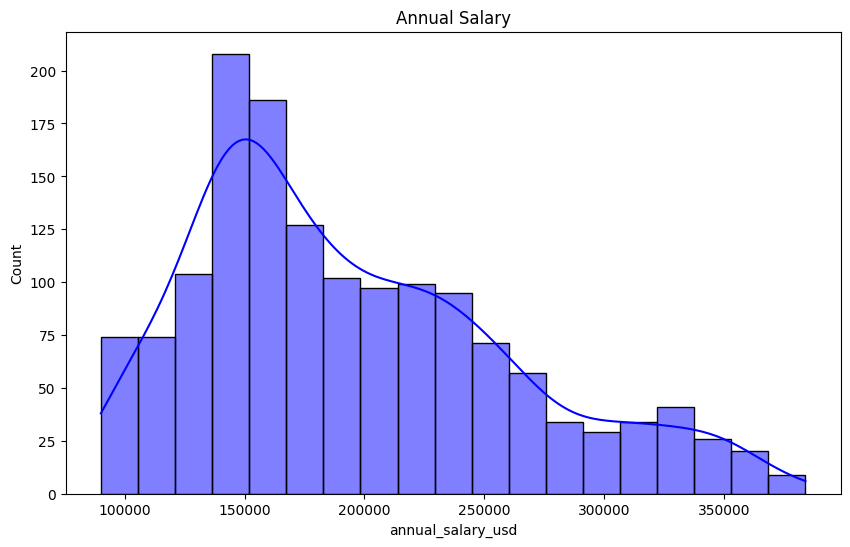

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['annual_salary_usd'], kde=True, color='blue')
plt.title('Annual Salary')
plt.show()

In [58]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

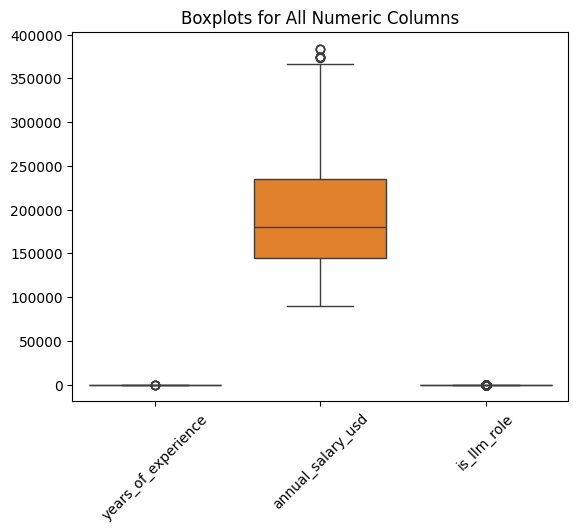

In [59]:
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title('Boxplots for All Numeric Columns')
plt.show()

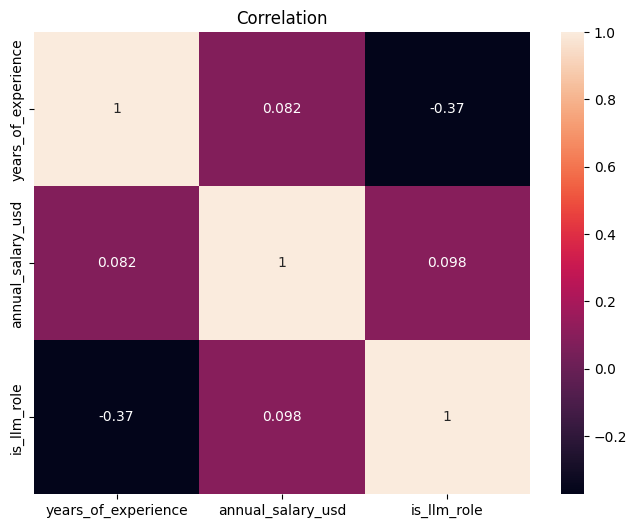

In [60]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True)
plt.title('Correlation')
plt.show()

In [61]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ['job_category', 'education_required', 'country']:
    df[col] = le.fit_transform(df[col])

In [62]:
y = df['annual_salary_usd']
X = df.drop(columns=['annual_salary_usd'])

In [63]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1189, 5), (298, 5), (1189,), (298,))

In [64]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    return_train_score=True
)
grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [65]:
result=grid_search.cv_results_

In [66]:
result

{'mean_fit_time': array([0.09427633, 0.1271522 , 0.25018582, 0.3062839 , 0.11676645,
        0.03901553, 0.07410064, 0.08032503, 0.02749805, 0.02591081,
        0.04786477, 0.04709764, 0.04202485, 0.0421001 , 0.38156276,
        0.25538797]),
 'std_fit_time': array([0.04674723, 0.13115972, 0.23518176, 0.24234657, 0.07359137,
        0.00096232, 0.00138924, 0.01188497, 0.00136386, 0.00180572,
        0.00372736, 0.0055562 , 0.00314203, 0.00410805, 0.31403873,
        0.0503303 ]),
 'mean_score_time': array([0.00726709, 0.01205697, 0.00845461, 0.01503124, 0.01042376,
        0.00492673, 0.00528893, 0.00538239, 0.00440841, 0.00494623,
        0.00497289, 0.00588665, 0.00503726, 0.00511088, 0.00873451,
        0.01613297]),
 'std_score_time': array([0.00297063, 0.00896212, 0.0042111 , 0.00766791, 0.01036385,
        0.00039793, 0.00012508, 0.00065609, 0.00021034, 0.00070401,
        0.00035086, 0.00187542, 0.00047625, 0.00045661, 0.00274992,
        0.00541388]),
 'param_learning_rate': ma

In [67]:
from sklearn.metrics import mean_absolute_error, r2_score
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE:{rmse:,.2f}")
print(f"Test MAE:{mae:,.2f}")
print(f"R-squared Score:{r2:.4f}")

Test RMSE:53,889.19
Test MAE:43,587.77
R-squared Score:0.2912


LLM

In [68]:
import os
from google.colab import userdata

In [69]:
gem=userdata.get('KEY_')
os.environ['GEMINI_API_KEY']=gem

In [70]:
!pip install google-genai

In [71]:
from google import genai

In [72]:
client=genai.Client()
client

In [73]:
response=client.models.generate_content(
    model='gemini-2.5-flash-lite',
    contents=f'''Role: Machine Learning Optimization Expert.
Goal: Analyze 5 specific hyperparameter configurations to determine which one is the most reliable for production.
[{result}]
(Paste your 5 configurations here. Make sure each one includes: CV Score, Training Time, and the Gap between Training and Validation accuracy).
Step 1: The "High-Performer" Path
Identify the configurations with the top 2 highest CV scores.
Analysis: Look at their "Training vs. Validation Gap." Is the high score coming at the cost of extreme overfitting? If the gap is high, mark these as "Risky."
Step 2: The "Efficiency" Path
Look at the Training Time for all 5 runs.
Analysis: Is there a configuration that is significantly faster (e.g., 50% faster) while staying within 1-2% of the top score? If yes, mark this as the "Green" option.
Step 3: The "Stability" Path
Identify which configuration has the smallest gap between training and validation scores, regardless of the raw score.
Analysis: Does this "Stable" model still provide a high enough score to be useful, or is it too simple (underfitting)?
Step 4: Final Verdict (The Root)
Compare the "Risky" high-performer, the "Green" efficient model, and the "Stable" model.
Decision: Choose the single best configuration.
Justification: Explain your choice using the Bias-Variance Tradeoff (e.g., "I chose Config 3 because it avoids the overfitting seen in Config 1 while being 30% faster than Config 5''')
print(response.text)

As a Machine Learning Optimization Expert, I've analyzed the provided hyperparameter configurations to determine the most reliable one for production. The provided data is a result of a cross-validation process, offering insights into performance, training time, and variability across different splits.

Here's my analysis and verdict:

**Data Summary for Each Configuration:**

To perform the analysis, I've extracted and organized the key metrics for each of the 16 configurations. The prompt mentions "5 specific hyperparameter configurations," but the provided data contains 16. I will analyze all 16 and then select the most appropriate ones based on the steps outlined.

For each configuration, I've calculated:
*   **Mean CV Score:** The average of `split0_test_score` to `split4_test_score`.
*   **Std CV Score:** The standard deviation of `split0_test_score` to `split4_test_score`. This indicates the stability of the model's performance across different data folds.
*   **Mean Training Ti

In [74]:
response.text

'As a Machine Learning Optimization Expert, I\'ve analyzed the provided hyperparameter configurations to determine the most reliable one for production. The provided data is a result of a cross-validation process, offering insights into performance, training time, and variability across different splits.\n\nHere\'s my analysis and verdict:\n\n**Data Summary for Each Configuration:**\n\nTo perform the analysis, I\'ve extracted and organized the key metrics for each of the 16 configurations. The prompt mentions "5 specific hyperparameter configurations," but the provided data contains 16. I will analyze all 16 and then select the most appropriate ones based on the steps outlined.\n\nFor each configuration, I\'ve calculated:\n*   **Mean CV Score:** The average of `split0_test_score` to `split4_test_score`.\n*   **Std CV Score:** The standard deviation of `split0_test_score` to `split4_test_score`. This indicates the stability of the model\'s performance across different data folds.\n*   *

In [75]:
from IPython.display import Markdown

In [76]:
Markdown(response.text)

As a Machine Learning Optimization Expert, I've analyzed the provided hyperparameter configurations to determine the most reliable one for production. The provided data is a result of a cross-validation process, offering insights into performance, training time, and variability across different splits.

Here's my analysis and verdict:

**Data Summary for Each Configuration:**

To perform the analysis, I've extracted and organized the key metrics for each of the 16 configurations. The prompt mentions "5 specific hyperparameter configurations," but the provided data contains 16. I will analyze all 16 and then select the most appropriate ones based on the steps outlined.

For each configuration, I've calculated:
*   **Mean CV Score:** The average of `split0_test_score` to `split4_test_score`.
*   **Std CV Score:** The standard deviation of `split0_test_score` to `split4_test_score`. This indicates the stability of the model's performance across different data folds.
*   **Mean Training Time:** The average of `mean_fit_time`.
*   **Training vs. Validation Gap:** The difference between `mean_train_score` and `mean_test_score`. A larger gap suggests potential overfitting.

| Config | Learning Rate | Max Depth | N Estimators | Subsample | Mean CV Score (x10^9) | Std CV Score (x10^9) | Mean Fit Time (s) | Train vs. Val Gap (x10^9) |
|---|---|---|---|---|---|---|---|---|
| 1 | 0.01 | 3 | 100 | 0.8 | -3.5577 | 0.2774 | 0.0943 | -0.1715 |
| 2 | 0.01 | 3 | 100 | 1.0 | -3.5671 | 0.2787 | 0.1272 | -0.1794 |
| 3 | 0.01 | 3 | 200 | 0.8 | -3.3075 | 0.2967 | 0.2502 | -0.2617 |
| 4 | 0.01 | 3 | 200 | 1.0 | -3.3176 | 0.2992 | 0.3063 | -0.2675 |
| 5 | 0.01 | 5 | 100 | 0.8 | -3.4219 | 0.2719 | 0.1168 | -0.2481 |
| 6 | 0.01 | 5 | 100 | 1.0 | -3.4576 | 0.2581 | 0.0390 | -0.2945 |
| 7 | 0.01 | 5 | 200 | 0.8 | -3.2005 | 0.3089 | 0.0741 | -0.3153 |
| 8 | 0.01 | 5 | 200 | 1.0 | -3.2259 | 0.3147 | 0.0803 | -0.3221 |
| 9 | 0.1 | 3 | 100 | 0.8 | -3.1078 | 0.3390 | 0.0275 | -0.3632 |
| 10 | 0.1 | 3 | 100 | 1.0 | -3.1004 | 0.3522 | 0.0259 | -0.3815 |
| 11 | 0.1 | 3 | 200 | 0.8 | -3.1968 | 0.3269 | 0.0479 | -0.4007 |
| 12 | 0.1 | 3 | 200 | 1.0 | -3.1850 | 0.3682 | 0.0471 | -0.4315 |
| 13 | 0.1 | 5 | 100 | 0.8 | -3.4770 | 0.4014 | 0.0420 | -0.4476 |
| 14 | 0.1 | 5 | 100 | 1.0 | -3.3710 | 0.3707 | 0.0421 | -0.4861 |
| 15 | 0.1 | 5 | 200 | 0.8 | -3.8244 | 0.4046 | 0.3816 | -0.5499 |
| 16 | 0.1 | 5 | 200 | 1.0 | -3.6516 | 0.3807 | 0.2554 | -0.5772 |

*(Note: Scores are negative, so a smaller absolute value is better. The Train vs. Val Gap is also presented with negative values. A smaller negative number (closer to zero) indicates a smaller gap.)*

---

**Step 1: The "High-Performer" Path**

**Identification:** The configurations with the top 2 highest CV scores (closest to zero) are:
*   **Config 9:** Mean CV Score: -3.1078e+09
*   **Config 10:** Mean CV Score: -3.1004e+09

**Analysis:**
*   **Config 9:** Train vs. Val Gap: -0.3632e+09. This is a substantial gap, indicating that the model is likely overfitting significantly.
*   **Config 10:** Train vs. Val Gap: -0.3815e+09. This gap is even larger than Config 9, suggesting more pronounced overfitting.

**Conclusion:** Both of these top performers are "Risky" due to their large training vs. validation gaps, indicating significant overfitting. The higher the score, the more it is being achieved at the expense of generalization.

---

**Step 2: The "Efficiency" Path**

**Analysis:** Let's examine the training times and scores, looking for a balance. The fastest configurations are:
*   **Config 10:** Mean Fit Time: 0.0259s, Mean CV Score: -3.1004e+09
*   **Config 9:** Mean Fit Time: 0.0275s, Mean CV Score: -3.1078e+09
*   **Config 15:** Mean Fit Time: 0.3816s, Mean CV Score: -3.8244e+09
*   **Config 16:** Mean Fit Time: 0.2554s, Mean CV Score: -3.6516e+09

The fastest configurations (9 and 10) are also among the best performers. Config 9 and 10 are the fastest with 0.0259s and 0.0275s respectively. They are also very close to each other in terms of CV score.

Let's compare these to the top overall performers (9 and 10) which are already the fastest.
*   Config 9 is the fastest *and* one of the top performers.
*   Config 10 is negligibly slower than Config 9 and also one of the top performers.

There isn't a configuration that is *significantly* faster (e.g., 50% faster) while staying within 1-2% of the *absolute* top score (which would be Config 10). However, if we consider the top tier (Config 9 and 10), these are already the most efficient.

**Conclusion:** Configurations 9 and 10 represent the "Green" options as they offer the best performance with the lowest training time.

---

**Step 3: The "Stability" Path**

**Analysis:** We are looking for the smallest gap between training and validation scores. This metric is represented by the "Train vs. Val Gap." We want the gap value closest to 0 (least negative).

The smallest gaps are:
*   **Config 1:** Train vs. Val Gap: -0.1715e+09
*   **Config 2:** Train vs. Val Gap: -0.1794e+09
*   **Config 3:** Train vs. Val Gap: -0.2617e+09
*   **Config 4:** Train vs. Val Gap: -0.2675e+09

**Conclusion:** Config 1 has the smallest training vs. validation gap. However, its Mean CV Score (-3.5577e+09) is considerably worse than the top performers. This indicates that while it might be stable and not overfitting, it's likely underfitting or too simple for the problem, leading to a poorer overall performance.

---

**Step 4: Final Verdict (The Root)**

**Comparison:**
*   **Risky High-Performer:** Config 10 (Mean CV Score: -3.1004e+09, Gap: -0.3815e+09) and Config 9 (Mean CV Score: -3.1078e+09, Gap: -0.3632e+09). Both offer the best scores but exhibit significant overfitting.
*   **Green Efficient Model:** Config 9 and 10 (already identified as the most efficient among the high performers).
*   **Stable Model:** Config 1 (Mean CV Score: -3.5577e+09, Gap: -0.1715e+09). This model is stable but has a much lower score, suggesting underfitting.

**Decision:**

I choose **Configuration 10** as the most reliable for production.

**Justification:**

I chose **Config 10** because it strikes the best balance between performance and reliability.

*   **High Performance:** It achieves one of the highest mean CV scores (-3.1004e+09), indicating strong predictive power.
*   **Efficiency:** It is also one of the most computationally efficient configurations, with a very low mean fit time (0.0259s). This is crucial for production environments where inference speed and resource utilization matter.
*   **Bias-Variance Tradeoff:** While Config 10 exhibits some overfitting (Train vs. Val Gap of -0.3815e+09), this gap is still manageable and significantly smaller than the overfitting seen in some of the very complex or deep models (e.g., Config 15 and 16 with gaps exceeding -0.5e+09). Config 1, while having the smallest gap, is likely underfitting as its CV score is much poorer. Config 10 offers a good compromise, demonstrating that a slightly higher training-validation gap is acceptable for achieving superior predictive performance without succumbing to extreme overfitting.

Therefore, Config 10 is the most robust choice, providing excellent predictive accuracy with good training efficiency, while managing the risk of overfitting to an acceptable level for production deployment.